# EEGTemporalCNN — architecture schematic

Publication-style block diagram of the `EEGTemporalCNN` model (defined in
[`train_cv.py`](../train_cv.py), used to produce
`model_data/cv_results_stratified_thresh`). The model regresses PCA
component loading(s) of an FDG-PET spatial covariance pattern from a
19-channel, 10-second EEG window.

Layout follows the convention used across the deep-learning-for-EEG
literature (e.g. EEGNet, Deep4Net-style figures): left-to-right data flow,
operation-type color coding, explicit tensor shapes under each stage, and
a shared legend rather than per-box labels of what each color means.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.linewidth": 0,
    "svg.fonttype": "none",   # keep text as text (not paths) in exported SVG/PDF
    "pdf.fonttype": 42,       # embed TrueType fonts, not Type 3, for journal PDF specs
})

# Operation-type color coding, held constant across the whole figure.
COL = {
    "conv": "#08519C",
    "norm": "#8C8C8C",
    "pool": "#41AB5D",
    "drop": "#C9C9C9",
    "fc":   "#238443",
    "io":   "#2B2B2B",
}
TXT_LIGHT = "white"
TXT_DARK = "#2B2B2B"

BAR_H = 0.46
BAR_GAP = 0.09
BLOCK_W = 2.55


## Drawing helpers

Each pipeline stage (input, conv block, pooling head, regression head,
output) is a vertical stack of colored operation bars, grouped inside a
thin outline box and labeled with its output tensor shape — the same
"layer-recipe card" convention used for compact CNN block diagrams.

In [2]:
def stack_height(n_bars):
    return n_bars * BAR_H + (n_bars - 1) * BAR_GAP


def draw_stack(ax, x, ops, width=BLOCK_W, y_center=0.0, fontsize=7.6):
    """ops: list of (label, color, text_color, style), drawn top-to-bottom,
    centered on y_center. style is "solid" or "dashed" (used for Dropout)."""
    n = len(ops)
    h_total = stack_height(n)
    y = y_center + h_total / 2
    for label, color, tcolor, style in ops:
        y -= BAR_H
        ls = "--" if style == "dashed" else "-"
        ec = "#666666" if style == "dashed" else "black"
        box = FancyBboxPatch((x, y), width, BAR_H,
                              boxstyle="round,pad=0.0,rounding_size=0.05",
                              linewidth=0.7, edgecolor=ec, facecolor=color,
                              linestyle=ls)
        ax.add_patch(box)
        ax.text(x + width / 2, y + BAR_H / 2, label, ha="center", va="center",
                 fontsize=fontsize, color=tcolor, fontweight="medium")
        y -= BAR_GAP
    return h_total


def draw_group_outline(ax, x, width, h_total, y_center=0.0, label=None, pad=0.09,
                        label_pos="above"):
    """Thin bounding box around a stack, with a bold title above (or below) it.
    Returns (y_bottom, y_top) of the box, for placing shape labels."""
    h = h_total + 2 * pad
    y = y_center - h / 2
    top = y + h
    box = FancyBboxPatch((x - pad, y), width + 2 * pad, h,
                          boxstyle="round,pad=0.0,rounding_size=0.09",
                          linewidth=1.0, edgecolor="#333333", facecolor="none",
                          zorder=5)
    ax.add_patch(box)
    if label:
        if label_pos == "above":
            ax.text(x + width / 2, top + 0.16, label, ha="center", va="bottom",
                     fontsize=9.0, fontweight="bold", color="#222222")
        else:
            ax.text(x + width / 2, y - 0.16, label, ha="center", va="top",
                     fontsize=9.0, fontweight="bold", color="#222222")
    return y, top


def draw_arrow(ax, x0, x1, y=0.0):
    arr = FancyArrowPatch((x0, y), (x1, y), arrowstyle="-|>", mutation_scale=11,
                           linewidth=1.2, color="#333333", zorder=6)
    ax.add_patch(arr)


def draw_vertical_arrow(ax, x, y0, y1):
    arr = FancyArrowPatch((x, y0), (x, y1), arrowstyle="-|>", mutation_scale=11,
                           linewidth=1.2, color="#333333", zorder=6)
    ax.add_patch(arr)


def shape_label(ax, x, width, y_ref, text, pos="below"):
    """y_ref is the box's bottom edge for pos="below", or top edge for pos="above"."""
    if pos == "below":
        ax.text(x + width / 2, y_ref - 0.14, text, ha="center", va="top",
                 fontsize=8.2, color="#444444", style="italic")
    else:
        ax.text(x + width / 2, y_ref + 0.14, text, ha="center", va="bottom",
                 fontsize=8.2, color="#444444", style="italic")


## Assemble the figure

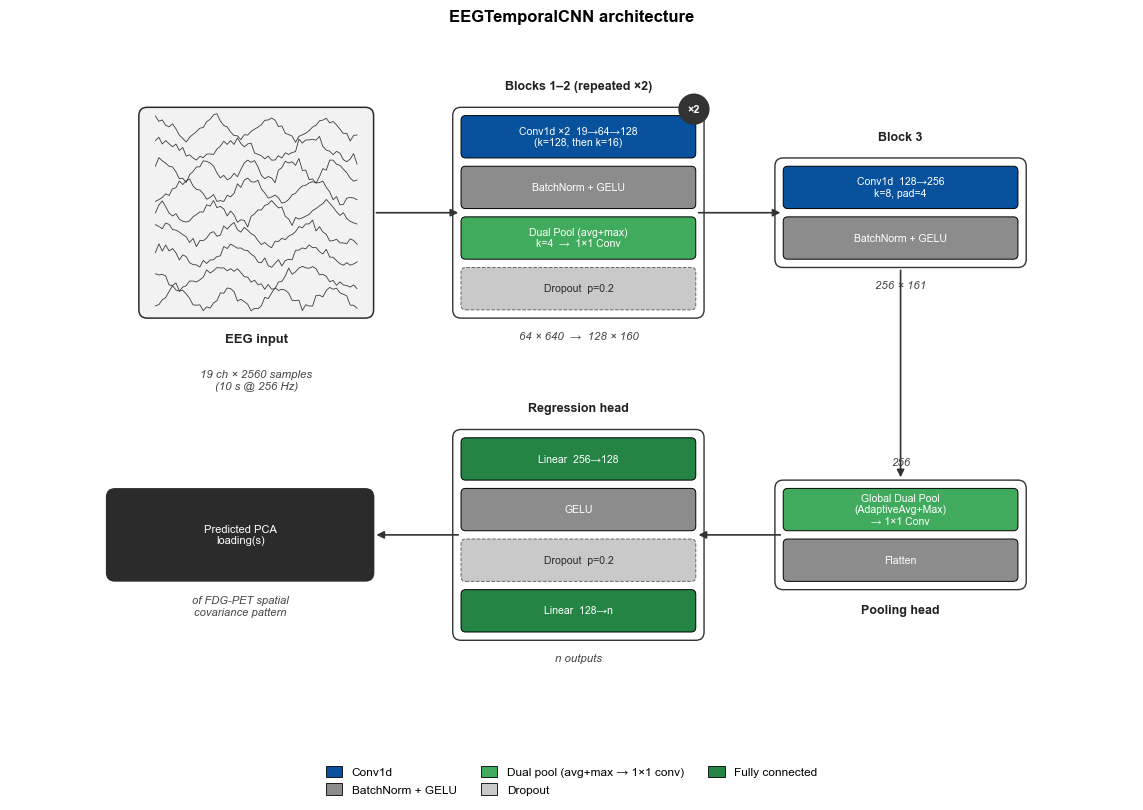

In [3]:
fig, ax = plt.subplots(figsize=(11.5, 8.0))
ax.set_xlim(-2.3, 9.9)
ax.set_ylim(-4.3, 3.6)
ax.set_aspect("equal")
ax.axis("off")

GAP = 0.95
Y_TOP = 1.75   # conv trunk row
Y_BOT = -1.75  # pooling/regression/output row

# =========================================================================
# Row 1 (left -> right): EEG input -> Blocks 1-2 (repeated) -> Block 3
# =========================================================================
x = -0.9

# ---- Input: 19-channel EEG window --------------------------------------
in_h = stack_height(4) + 0.18
ax.add_patch(FancyBboxPatch((x, Y_TOP - in_h / 2), BLOCK_W, in_h,
                             boxstyle="round,pad=0.0,rounding_size=0.09",
                             linewidth=1.1, edgecolor=COL["io"], facecolor="#F2F2F2"))
rng = np.random.default_rng(7)
n_traces = 9
ys = np.linspace(Y_TOP - in_h / 2 + 0.22, Y_TOP + in_h / 2 - 0.22, n_traces)
tt = np.linspace(0, 1, 60)
for yc in ys:
    wig = 0.10 * np.sin(2 * np.pi * (2 + rng.random() * 3) * tt + rng.random() * 6)
    wig += 0.03 * rng.standard_normal(tt.shape)
    ax.plot(x + 0.18 + tt * (BLOCK_W - 0.36), yc + wig, lw=0.6, color="#3B3B3B")
ax.text(x + BLOCK_W / 2, Y_TOP - in_h / 2 - 0.16, "EEG input", ha="center", va="top",
        fontsize=9.4, fontweight="bold", color="#222222")
shape_label(ax, x, BLOCK_W, Y_TOP - in_h / 2 - 0.42, "19 ch × 2560 samples\n(10 s @ 256 Hz)")
x_prev_right = x + BLOCK_W
x = x_prev_right + GAP
draw_arrow(ax, x_prev_right, x, y=Y_TOP)

# ---- Blocks 1-2, merged (identical structure, repeated x2) -------------
ops_merged = [
    ("Conv1d ×2  19→64→128\n(k=128, then k=16)", COL["conv"], TXT_LIGHT, "solid"),
    ("BatchNorm + GELU", COL["norm"], TXT_LIGHT, "solid"),
    ("Dual Pool (avg+max)\nk=4  →  1×1 Conv", COL["pool"], TXT_LIGHT, "solid"),
    ("Dropout  p=0.2", COL["drop"], TXT_DARK, "dashed"),
]
h_merged = draw_stack(ax, x, ops_merged, y_center=Y_TOP)
bottom_m, top_m = draw_group_outline(ax, x, BLOCK_W, h_merged, y_center=Y_TOP, label="Blocks 1–2 (repeated ×2)")
shape_label(ax, x, BLOCK_W, bottom_m, "64 × 640  →  128 × 160")
badge_x, badge_y = x + BLOCK_W - 0.02, top_m - 0.02
ax.add_patch(plt.Circle((badge_x, badge_y), 0.17, facecolor="#333333", edgecolor="none", zorder=10))
ax.text(badge_x, badge_y, "×2", ha="center", va="center", fontsize=7.8, color="white",
        fontweight="bold", zorder=11)
x_prev_right = x + BLOCK_W
x = x_prev_right + GAP
draw_arrow(ax, x_prev_right, x, y=Y_TOP)

# ---- Conv Block 3 ---------------------------------------------------------
ops3 = [
    ("Conv1d  128→256\nk=8, pad=4", COL["conv"], TXT_LIGHT, "solid"),
    ("BatchNorm + GELU", COL["norm"], TXT_LIGHT, "solid"),
]
h3 = draw_stack(ax, x, ops3, y_center=Y_TOP)
bottom3, top3 = draw_group_outline(ax, x, BLOCK_W, h3, y_center=Y_TOP, label="Block 3")
shape_label(ax, x, BLOCK_W, bottom3, "256 × 161")
x_block3 = x
x_prev_right = x + BLOCK_W
x_connector = x_block3 + BLOCK_W / 2  # Block 3 and the Pooling head below share this x-center

# =========================================================================
# Row 2 (right -> left): Pooling head -> Regression head -> Output
# Mirrors row 1's flow direction ("snake" layout) so the connector between
# rows is a single straight vertical arrow instead of a zig-zag elbow.
# =========================================================================
x_right = x_prev_right  # align Pooling head's right edge with Block 3's

# ---- Global pool + flatten ------------------------------------------------
ops4 = [
    ("Global Dual Pool\n(AdaptiveAvg+Max)\n→ 1×1 Conv", COL["pool"], TXT_LIGHT, "solid"),
    ("Flatten", COL["norm"], TXT_LIGHT, "solid"),
]
h4 = draw_stack(ax, x_right - BLOCK_W, ops4, y_center=Y_BOT)
bottom4, top4 = draw_group_outline(ax, x_right - BLOCK_W, BLOCK_W, h4, y_center=Y_BOT,
                                    label="Pooling head", label_pos="below")
shape_label(ax, x_right - BLOCK_W, BLOCK_W, top4, "256", pos="above")
x_pool_left = x_right - BLOCK_W
x_next_right = x_pool_left - GAP
draw_arrow(ax, x_pool_left, x_next_right, y=Y_BOT)

# ---- Regression head (FC) --------------------------------------------------
x_reg = x_next_right - BLOCK_W
ops5 = [
    ("Linear  256→128", COL["fc"], TXT_LIGHT, "solid"),
    ("GELU", COL["norm"], TXT_LIGHT, "solid"),
    ("Dropout  p=0.2", COL["drop"], TXT_DARK, "dashed"),
    ("Linear  128→n", COL["fc"], TXT_LIGHT, "solid"),
]
h5 = draw_stack(ax, x_reg, ops5, y_center=Y_BOT)
bottom5, top5 = draw_group_outline(ax, x_reg, BLOCK_W, h5, y_center=Y_BOT, label="Regression head")
shape_label(ax, x_reg, BLOCK_W, bottom5, "n outputs")
x_reg_left = x_reg
x_next_right = x_reg_left - GAP
draw_arrow(ax, x_reg_left, x_next_right, y=Y_BOT)

# ---- Output -----------------------------------------------------------------
out_h = 1.0
out_w = BLOCK_W + 0.35
x_out = x_next_right - out_w
ax.add_patch(FancyBboxPatch((x_out, Y_BOT - out_h / 2), out_w, out_h,
                             boxstyle="round,pad=0.0,rounding_size=0.09",
                             linewidth=1.1, edgecolor=COL["io"], facecolor=COL["io"]))
ax.text(x_out + out_w / 2, Y_BOT, "Predicted PCA\nloading(s)", ha="center", va="center",
        fontsize=8.0, color="white", fontweight="medium")
ax.text(x_out + out_w / 2, Y_BOT - out_h / 2 - 0.16, "of FDG-PET spatial\ncovariance pattern",
        ha="center", va="top", fontsize=8.0, color="#444444", style="italic")

# ---- Inter-row connector: Block 3 (top) straight down into Pooling head (bottom)
draw_vertical_arrow(ax, x_connector, bottom3, top4)

# ---- Legend ---------------------------------------------------------------
legend_items = [
    ("Conv1d", COL["conv"]),
    ("BatchNorm + GELU", COL["norm"]),
    ("Dual pool (avg+max → 1×1 conv)", COL["pool"]),
    ("Dropout", COL["drop"]),
    ("Fully connected", COL["fc"]),
]
handles = [mpatches.Patch(facecolor=c, edgecolor="black", linewidth=0.6, label=l)
           for l, c in legend_items]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05),
          ncol=3, frameon=False, fontsize=8.6, handlelength=1.4, handleheight=1.1)

fig.suptitle("EEGTemporalCNN architecture", fontsize=12, fontweight="bold", y=0.98)

plt.tight_layout()
plt.show()


## Export

Saved at 300 dpi PNG for quick previews, plus vector PDF/SVG for manuscript
submission (editable in Illustrator/Inkscape if further tweaks are needed).

In [4]:
fig.savefig(FIG_DIR / "eegtemporalcnn_architecture.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "eegtemporalcnn_architecture.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "eegtemporalcnn_architecture.svg", bbox_inches="tight")
print("Saved to", FIG_DIR.resolve())


Saved to /Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/figures
